In [53]:
import pandas as pd
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torchmetrics as tm

In [54]:
device = "cuda"
root_path = "/home/stefan/ioai-prep/kits/gaia/scrambeled"

# Data

In [55]:
train = np.load(f"{root_path}/train_data.npz")
test = np.load(f"{root_path}/test_data.npz")

labels = train["labels"]

pos0 = train["pos0"].astype(np.float32)
pos2 = train["pos2"].astype(np.float32)
pos3 = train["pos3"].astype(np.float32)
t0 = test["pos0"].astype(np.float32)
t2 = test["pos2"].astype(np.float32)
t3 = test["pos3"].astype(np.float32)

In [56]:
X = np.concatenate([pos0, pos2, pos3, pos0 * pos2], axis=1)
X_test = np.concatenate([t0, t2, t3, t0 * t2], axis=1)

mean = X.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True) + 1e-8
X = (X - mean) / std
X_test = (X_test - mean) / std

In [57]:
perm = np.random.RandomState(42).permutation(len(X))
split = int(0.9 * len(X))
train_idx, val_idx = perm[:split], perm[split:]

X_train, y_train = X[train_idx], labels[train_idx]
X_val, y_val = X[val_idx], labels[val_idx]

train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_dataset = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_dataset = TensorDataset(torch.from_numpy(X_test))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")

train: (18000, 20480), val: (2000, 20480), test: (10000, 20480)


# Model

In [58]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(20480, 1024)
        self.bn = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 100)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.dropout(F.relu(self.bn(self.fc1(x))))
        x = self.fc2(x)
        return x


model = MLP().to(device)

batch = next(iter(train_loader))
model(batch[0].to(device)).shape

torch.Size([256, 100])

In [59]:
not_loaded = True

if not not_loaded:
    model.load_state_dict(torch.load(f"{root_path}/best.pt"))

In [60]:
epochs = 30 if not_loaded else 0
lr = 1e-3
best_so_far = 0

optimizer = torch.optim.AdamW(model.parameters(), lr, weight_decay=0.3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()
acc = tm.Accuracy(task="multiclass", num_classes=100).to(device)

In [61]:
for epoch in range(1, epochs + 1):
    model.train()
    t_loss = 0.0
    for features, lbl in tqdm(train_loader, desc="train"):
        features, lbl = features.to(device), lbl.to(device)

        logits = model(features)
        loss = criterion(logits, lbl)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        t_loss += loss.item()
    scheduler.step()

    model.eval()
    v_loss = 0.0
    acc.reset()
    with torch.no_grad():
        for features, lbl in tqdm(val_loader, desc="val"):
            features, lbl = features.to(device), lbl.to(device)
            logits = model(features)
            loss = criterion(logits, lbl)
            acc(logits, lbl)
            v_loss += loss.item()

    t_loss = t_loss / len(train_loader)
    v_loss = v_loss / len(val_loader)
    if acc.compute() * 100 > best_so_far:
        best_so_far = acc.compute() * 100
        print("new best!")
        torch.save(model.state_dict(), f"{root_path}/best.pt")
    print(
        f"epoch {epoch}: t_loss={t_loss:.4f}, v_loss={v_loss:.4f}, val_acc={acc.compute()*100:.2f}"
    )

val: 100%|██████████| 8/8 [00:00<00:00, 133.33it/s]


new best!
epoch 1: t_loss=2.4057, v_loss=1.9373, val_acc=47.10


val: 100%|██████████| 8/8 [00:00<00:00, 128.62it/s]


new best!
epoch 2: t_loss=1.5249, v_loss=1.8340, val_acc=48.75


val: 100%|██████████| 8/8 [00:00<00:00, 124.75it/s]


...

new best!
epoch 28: t_loss=0.0048, v_loss=1.9242, val_acc=52.50


val: 100%|██████████| 8/8 [00:00<00:00, 126.60it/s]


epoch 29: t_loss=0.0047, v_loss=1.9244, val_acc=52.10


val: 100%|██████████| 8/8 [00:00<00:00, 122.58it/s]

epoch 30: t_loss=0.0048, v_loss=1.9235, val_acc=52.15


In [62]:
model.load_state_dict(torch.load(f"{root_path}/best.pt"))

<All keys matched successfully>

# Submission

100%|██████████| 40/40 [00:00<00:00, 138.77it/s]


,subtaskID,datapointID,answer
0,1,0,68
1,1,1,33
2,1,2,30
3,1,3,51
4,1,4,71


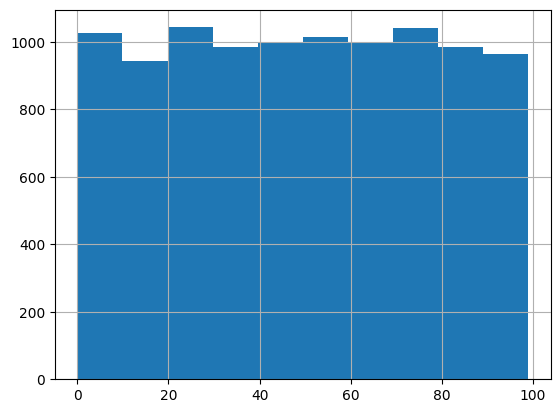

In [63]:
model.eval()

predictions = []
with torch.no_grad():
    for features, in tqdm(test_loader):
        features = features.to(device)
        pred = model(features).argmax(dim=-1)
        predictions.extend(pred.cpu().numpy().tolist())

sub = pd.DataFrame({
    "subtaskID": 1,
    "datapointID": np.arange(len(predictions)),
    "answer": predictions,
})

sub.to_csv(f"{root_path}/submission.csv", index=False)
sub["answer"].hist()
sub.head()